<a href="https://colab.research.google.com/github/yash221271-cloud/ICICI_fintech/blob/main/Colorectal_cancer_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df=pd.read_csv("colorectal_cancer_prediction.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89945 entries, 0 to 89944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               89945 non-null  int64  
 1   Age                      89945 non-null  int64  
 2   Gender                   89945 non-null  object 
 3   Race                     89945 non-null  object 
 4   Region                   89945 non-null  object 
 5   Urban_or_Rural           89945 non-null  object 
 6   Socioeconomic_Status     89945 non-null  object 
 7   Family_History           89945 non-null  object 
 8   Previous_Cancer_History  89945 non-null  object 
 9   Stage_at_Diagnosis       89945 non-null  object 
 10  Tumor_Aggressiveness     89945 non-null  object 
 11  Colonoscopy_Access       89945 non-null  object 
 12  Screening_Regularity     89945 non-null  object 
 13  Diet_Type                89945 non-null  object 
 14  BMI                   

Exploratory Data Analysis [EDA]


### Checking for Missing Values

In [ ]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Missing values in each column:")
    display(missing_values.sort_values(ascending=False))
else:
    print("No missing values found in the DataFrame.")

No missing values found in the DataFrame.


### Correlation Heatmap of Numerical Features

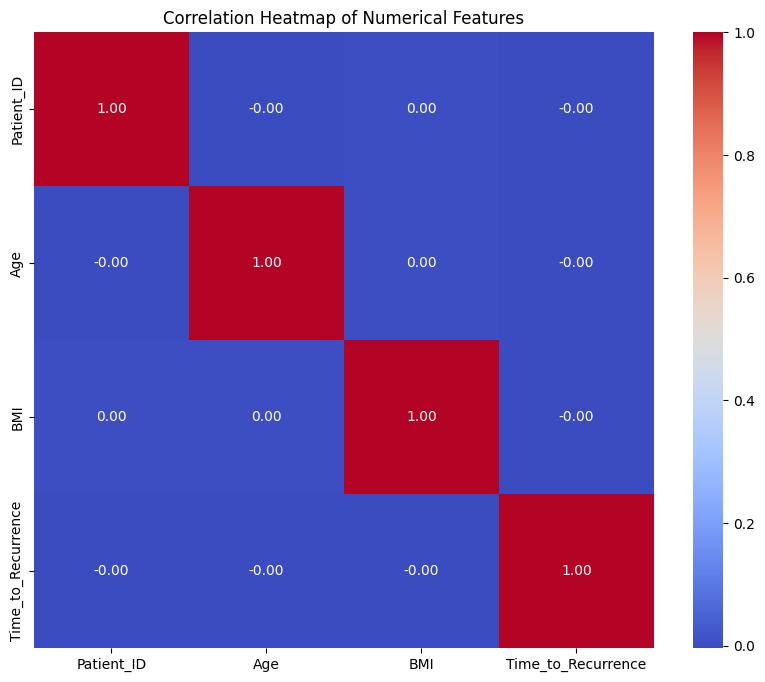

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Dropping 'Recurrence' and 'Time_to_Recurrence' to prevent data leakage

In [ ]:
# Drop 'Patient_ID' as it's an identifier and not a feature for prediction
df_processed = df.drop('Patient_ID', axis=1)

# Identify categorical columns for one-hot encoding (excluding the target variable)
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()
if 'Survival_Status' in categorical_cols:
    categorical_cols.remove('Survival_Status') # Ensure target is not encoded here

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

columns_to_drop_for_prediction = ['Recurrence_Yes', 'Time_to_Recurrence'] # 'Recurrence_Yes' is the one-hot encoded column for Recurrence

# Ensure the columns exist before dropping
existing_columns_to_drop = [col for col in columns_to_drop_for_prediction if col in df_processed.columns]

if existing_columns_to_drop:
    df_processed = df_processed.drop(columns=existing_columns_to_drop, axis=1)
    print(f"Dropped columns: {existing_columns_to_drop}")
    print(f"Shape of DataFrame after dropping columns: {df_processed.shape}")
else:
    print("Columns 'Recurrence_Yes' and 'Time_to_Recurrence' were not found or already dropped.")

display(df_processed.head())

Dropped columns: ['Recurrence_Yes', 'Time_to_Recurrence']
Shape of DataFrame after dropping columns: (89945, 44)


,Age,BMI,Survival_Status,Gender_Male,Race_Black,Race_Hispanic,Race_Other,Race_White,Region_Asia Pacific,Region_Europe,Region_Latin America,Region_North America,Urban_or_Rural_Urban,Socioeconomic_Status_Low,Socioeconomic_Status_Middle,Family_History_Yes,Previous_Cancer_History_Yes,Stage_at_Diagnosis_II,Stage_at_Diagnosis_III,Stage_at_Diagnosis_IV,Tumor_Aggressiveness_Low,Tumor_Aggressiveness_Medium,Colonoscopy_Access_Yes,Screening_Regularity_Never,Screening_Regularity_Regular,Diet_Type_Traditional,Diet_Type_Western,Physical_Activity_Level_Low,Physical_Activity_Level_Medium,Smoking_Status_Former,Smoking_Status_Never,Alcohol_Consumption_Low,Alcohol_Consumption_Medium,Red_Meat_Consumption_Low,Red_Meat_Consumption_Medium,Fiber_Consumption_Low,Fiber_Consumption_Medium,Insurance_Coverage_Yes,Time_to_Diagnosis_Timely,Treatment_Access_Limited,Chemotherapy_Received_Yes,Radiotherapy_Received_Yes,Surgery_Received_Yes,Follow_Up_Adherence_Poor
0,71,33.0,Survived,True,False,False,True,False,False,True,False,False,True,False,True,True,False,False,True,False,False,False,False,False,True,False,True,True,False,False,True,True,False,True,False,True,False,True,False,False,True,False,False,False
1,34,33.1,Deceased,False,True,False,False,False,False,False,False,True,True,False,True,False,False,False,False,False,False,True,True,False,True,False,True,False,True,False,True,True,False,True,False,True,False,False,True,False,False,True,True,True
2,80,20.7,Survived,False,False,False,False,True,False,False,False,True,True,False,True,False,False,False,True,False,True,False,True,False,True,False,False,False,True,False,True,True,False,True,False,False,True,True,True,True,False,True,True,False
3,40,38.9,Deceased,True,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,True,True,False,True,False,False,True,True,False,True,False,True,False,False,False,True,False,True,True,False,True,True
4,43,24.8,Deceased,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,True,False,True,True,False,True,False,False,True,True,False,False,False,False,True,True,False,False,False,False,True,False,True,True


### Define Features (X) and Target Variable (y)

In [ ]:
X = df_processed.drop('Survival_Status', axis=1)
y = df_processed['Survival_Status']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (89945, 43)
Shape of target (y): (89945,)


### Split Data into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (71956, 43)
Shape of X_test: (17989, 43)
Shape of y_train: (71956,)
Shape of y_test: (17989,)


### Train a Logistic Regression Model

In [ ]:
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for smaller datasets or L1/L2 regularization
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Evaluate Model Performance

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7486797487353383

Confusion Matrix:
 [[    0  4521]
 [    0 13468]]

Classification Report:
               precision    recall  f1-score   support

    Deceased       0.00      0.00      0.00      4521
    Survived       0.75      1.00      0.86     13468

    accuracy                           0.75     17989
   macro avg       0.37      0.50      0.43     17989
weighted avg       0.56      0.75      0.64     17989



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Interpretation of Model Performance

The accuracy, confusion matrix, and classification report provide insights into how well the Logistic Regression model performs in predicting 'Survival_Status'.

*   **Accuracy:** This metric tells us the proportion of correctly classified instances out of the total instances.
*   **Confusion Matrix:** This matrix shows the number of correct and incorrect predictions made by the classification model compared to the actual outcomes. It helps in understanding the types of errors made (False Positives and False Negatives).
    *   **True Positives (TP):** Correctly predicted as the positive class.
    *   **True Negatives (TN):** Correctly predicted as the negative class.
    *   **False Positives (FP):** Incorrectly predicted as the positive class (Type I error).
    *   **False Negatives (FN):** Incorrectly predicted as the negative class (Type II error).
*   **Classification Report:** This report provides a more detailed breakdown of performance metrics for each class, including Precision, Recall, and F1-score.
    *   **Precision:** The ability of the classifier not to label as positive a sample that is negative (TP / (TP + FP)).
    *   **Recall:** The ability of the classifier to find all the positive samples (TP / (TP + FN)).
    *   **F1-Score:** The harmonic mean of precision and recall, providing a single metric that balances both.

Based on these metrics, we can assess the model's effectiveness in distinguishing between 'Survived' and 'Deceased' patients.

### Addressing Class Imbalance

The current classification report clearly shows that the model is performing very poorly on the 'Deceased' class, with precision, recall, and f1-score all at 0.00. This is a classic symptom of **class imbalance**, where one class (in this case, 'Survived') has significantly more samples than the other ('Deceased').

Because the model sees very few examples of the 'Deceased' class during training, it struggles to learn patterns associated with it and tends to classify almost all instances as the majority class ('Survived').

To address this, we can use **oversampling techniques** to increase the number of samples in the minority class. One popular method is **SMOTE (Synthetic Minority Over-sampling Technique)**, which creates synthetic samples for the minority class. This helps the model learn more effectively from the underrepresented class.

In [ ]:
# Install imblearn if not already installed
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

# Before SMOTE, let's check the class distribution in the training set
print("Class distribution before SMOTE in y_train:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE in y_train_res:")
print(y_train_res.value_counts())

Class distribution before SMOTE in y_train:
Survival_Status
Survived    53873
Deceased    18083
Name: count, dtype: int64

Class distribution after SMOTE in y_train_res:
Survival_Status
Survived    53873
Deceased    53873
Name: count, dtype: int64


As you can see, after applying SMOTE, the 'Deceased' class in the training set (`y_train_res`) now has an equal number of samples as the 'Survived' class. This balanced dataset should help the model learn the characteristics of the minority class more effectively.

### Retrain Model with Balanced Data

In [ ]:
# Retrain the Logistic Regression model using the SMOTE-resampled training data
model_resampled = LogisticRegression(random_state=42, solver='liblinear')
model_resampled.fit(X_train_res, y_train_res)

print("Logistic Regression model retrained successfully with SMOTE data!")

Logistic Regression model retrained successfully with SMOTE data!


### Evaluate Retrained Model Performance

In [ ]:
# Make predictions on the original (unbalanced) test set using the retrained model
y_pred_resampled = model_resampled.predict(X_test)

print("Accuracy (Resampled Model):", accuracy_score(y_test, y_pred_resampled))
print("\nConfusion Matrix (Resampled Model):\n", confusion_matrix(y_test, y_pred_resampled))
print("\nClassification Report (Resampled Model):\n", classification_report(y_test, y_pred_resampled))

Accuracy (Resampled Model): 0.6571237978764801

Confusion Matrix (Resampled Model):
 [[  872  3649]
 [ 2519 10949]]

Classification Report (Resampled Model):
               precision    recall  f1-score   support

    Deceased       0.26      0.19      0.22      4521
    Survived       0.75      0.81      0.78     13468

    accuracy                           0.66     17989
   macro avg       0.50      0.50      0.50     17989
weighted avg       0.63      0.66      0.64     17989



### Further Model Improvement: Random Forest Classifier

To explore further model improvements, we will now train a Random Forest Classifier. Random Forests are powerful ensemble learning methods that can often provide better accuracy and handle complex relationships in the data compared to logistic regression. They are also less sensitive to outliers and can provide insights into feature importance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier on SMOTE-resampled data
# Using class_weight='balanced' to give more importance to the minority class
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_model.fit(X_train_res, y_train_res)

print("Random Forest Classifier trained successfully with SMOTE data and class weights!")

Random Forest Classifier trained successfully with SMOTE data and class weights!


### Evaluate Random Forest Model Performance

In [ ]:
# Make predictions on the original (unbalanced) test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

print("Accuracy (Random Forest Model):", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix (Random Forest Model):\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report (Random Forest Model):\n", classification_report(y_test, y_pred_rf))

Accuracy (Random Forest Model): 0.712768914336539

Confusion Matrix (Random Forest Model):
 [[  324  4197]
 [  970 12498]]

Classification Report (Random Forest Model):
               precision    recall  f1-score   support

    Deceased       0.25      0.07      0.11      4521
    Survived       0.75      0.93      0.83     13468

    accuracy                           0.71     17989
   macro avg       0.50      0.50      0.47     17989
weighted avg       0.62      0.71      0.65     17989



### Generate Predictions

In [ ]:
# Make predictions on the test set
y_pred_new = model.predict(X_test)

# Display the first few predictions
print("First 10 predictions:", y_pred_new[:10])
print("Corresponding actual values:", y_test[:10].values)

First 10 predictions: ['Survived' 'Survived' 'Survived' 'Survived' 'Survived' 'Survived'
 'Survived' 'Survived' 'Survived' 'Survived']
Corresponding actual values: ['Survived' 'Survived' 'Survived' 'Deceased' 'Survived' 'Survived'
 'Deceased' 'Deceased' 'Survived' 'Survived']
